# BoE_IR-MPR_Sentiment_Analysis_LM_VADER_v1.ipynb [FG]

<div class="alert alert-block alert-info">
Notebook Start

# LSE | Bank of England: Inflation & Monetary Policy Reports (IR/MPR)
### Sentiment Analysis using Loughran–McDonald (LM) and VADER

**Purpose**  
Analyse how the tone and sentiment of the Bank’s key macroeconomic publications (the *Inflation Report* (1998–2019) and its successor, the *Monetary Policy Report* (2019–present)) have evolved over time.  
The analysis uses two complementary approaches:
- **Loughran–McDonald (LM)**: captures *risk-oriented language* typical in financial and policy contexts.  
- **VADER**: measures the *surface tone* of communication (positive, neutral, negative) in general English.  

Together, they provide a balanced view of both **substance** (risk narrative) and **tone** (communication style).

**Scope**  
- **Files:** PDFs stored in `pdfs/inflation_reports/`, including both `inflation_report_<month>-<year>.pdf` and `monetary-policy-report_<month>-<year>.pdf`.  
- **Coverage:** 1998–2022+, around 87 reports in total.  
- **Outputs:** Metrics per report, yearly medians, and comparative charts saved to `outputs/`.

**Method**  
1. **Extract text** from each PDF using *PyMuPDF* (`fitz`).  
2. **Normalise text** (lower-case, remove punctuation, split on whitespace).  
3. **Apply LM dictionary** (finance-specific categories) to compute per-1,000 rates and indices.  
4. **Apply VADER** sentiment on the same text.  
5. **Combine outputs**, derive dates from filenames, and **aggregate yearly medians**.  
6. **Visualise** LM, VADER, and **LM vs VADER**.

**Outputs generated automatically**  
- `infl_mpr_documents_summary.csv`: one row per report with LM + VADER metrics  
- `infl_mpr_term_matches_long.csv`: every matched term (for audits)  
- PNG charts in `outputs/`:
  - `infl_mpr_uncertainty_per_1000.png`  
  - `infl_mpr_negative_per_1000.png`  
  - `infl_mpr_net_sent_yearly_median.png`  
  - `infl_mpr_net_strength_yearly_median.png`  
  - `infl_mpr_vader_compound_yearly_median.png`  
  - `infl_mpr_lm_vs_vader_yearly_medians.png`

**Note**  
The Inflation Report and the Monetary Policy Report are treated as a *single continuous publication* for consistency, as the latter replaced the former in late 2019.

## Step 1: Imports and Folder Setup

We begin by importing all the necessary Python libraries and defining the folder structure for this notebook.  
The setup follows exactly the same format used for the Financial Stability Reports analysis, but points to the `pdfs/inflation_reports` folder which contains both the *Inflation Reports* and the *Monetary Policy Reports*.

All outputs (tables, charts, and CSVs) will be saved into the shared `outputs` directory within the project folder.

In [1]:
from pathlib import Path
import re
from collections import Counter

import pandas as pd
import numpy as np

## Step 3: Text Extraction and Normalisation

In this step, we extract text from each Inflation or Monetary Policy Report and clean it for analysis.  
We use **PyMuPDF** (`fitz`) for extraction, as in the previous notebook, ensuring consistent and reliable text output from each PDF.

The extracted text is then normalised (converted to lowercase, punctuation removed, hyphens replaced with spaces, and multiple spaces collapsed), so that the words can be matched accurately to the Loughran–McDonald sentiment dictionary later in the process.

In [2]:
# Paths
ROOT = Path(".")
PDF_FOLDER = ROOT / "pdfs" / "inflation_reports"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SUM_CSV  = OUT_DIR / "infl_mpr_documents_summary.csv"
LONG_CSV = OUT_DIR / "infl_mpr_term_matches_long.csv"

# Text extractor (PyMuPDF)
import sys, subprocess
try:
    import fitz  # PyMuPDF
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pymupdf"])
    import fitz

PUNCT_RE = re.compile(r"[^\w\s']+", flags=re.UNICODE)

def extract_text_from_pdf(pdf_path: Path) -> str:
    parts = []
    with fitz.open(pdf_path) as doc:
        for page in doc:
            parts.append(page.get_text("text"))
    return "\n".join(parts)

def normalise_text(s: str) -> str:
    s = s.lower().replace("-", " ")
    s = PUNCT_RE.sub(" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def tokenise(s: str):
    return s.split()

## Step 3: Load the Loughran–McDonald Dictionary

We now load the **Loughran–McDonald (LM)** finance-specific sentiment dictionary, exactly as in the Financial Stability analysis.  
This dictionary categorises thousands of financial terms into sentiment and tone-related groups, including *positive, negative, uncertainty, litigious, constraining, strong,* and *weak.*

Loading the dictionary at this stage allows us to create reusable sets of words for each category.  
These sets will be used to classify every word in the Inflation and Monetary Policy Reports according to its sentiment or tone.

In [3]:
DICT_XLSX  = ROOT / "LSE_DA_BoE_Employer_project_Sentiment-labelled_wordlist-2-1.xlsx"
DICT_SHEET = "Loughran-McDonald_MasterDiction"

lex = pd.read_excel(DICT_XLSX, sheet_name=DICT_SHEET)
lex.columns = [c.strip() for c in lex.columns]

required = {"Word","Negative","Positive","Uncertainty","Litigious","Strong","Weak","Constraining"}
missing = required - set(lex.columns)
if missing:
    raise ValueError(f"Dictionary missing columns: {missing}")

label_cols = [c for c in lex.columns if c != "Word"]
lex[label_cols] = lex[label_cols].fillna(0)
lex["Word"] = lex["Word"].astype(str).str.strip().str.lower()
lex = lex[(lex[label_cols] != 0).any(axis=1)].copy()

LM = {
    "positive":     set(lex.loc[lex["Positive"]     != 0, "Word"]),
    "negative":     set(lex.loc[lex["Negative"]     != 0, "Word"]),
    "uncertainty":  set(lex.loc[lex["Uncertainty"]  != 0, "Word"]),
    "litigious":    set(lex.loc[lex["Litigious"]    != 0, "Word"]),
    "strong":       set(lex.loc[lex["Strong"]       != 0, "Word"]),
    "weak":         set(lex.loc[lex["Weak"]         != 0, "Word"]),
    "constraining": set(lex.loc[lex["Constraining"] != 0, "Word"]),}

{k: len(v) for k,v in LM.items()}

{'positive': 358,
 'negative': 2355,
 'uncertainty': 297,
 'litigious': 905,
 'strong': 19,
 'weak': 27,
 'constraining': 184}

## Step 4: Parse Filenames and Extract Dates

Before running the sentiment analysis, we identify each report’s **series, month, and year** directly from its filename.  
This ensures that every report can be placed correctly on a timeline when we produce charts and yearly medians later.

The filenames follow two consistent patterns:
- `inflation_report_<month>-<year>.pdf`
- `monetary-policy-report_<month>-<year>.pdf`

We extract this information and convert it into a proper `report_date` field (year and month), so that both the Inflation and Monetary Policy Reports are treated as one continuous publication series.

In [4]:
MONTH_MAP = {
    "JANUARY":1,"FEBRUARY":2,"MARCH":3,"APRIL":4,"MAY":5,"JUNE":6,
    "JULY":7,"AUGUST":8,"SEPTEMBER":9,"OCTOBER":10,"NOVEMBER":11,"DECEMBER":12}

PATTERN = re.compile(
    r"^(?P<series>(?:inflation[_-]report|monetary[-]policy[-]report))[_-]"
    r"(?P<month>[a-z]+)-(?P<year>\d{4})$")

def parse_name(stem: str):
    m = PATTERN.match(stem.lower())
    if not m:
        return {"series": None, "month_name": None, "year": None, "month": None}
    series_token = m.group("series")
    series = "Inflation Report" if "inflation" in series_token else "Monetary Policy Report"
    month_name = m.group("month").upper()
    year = int(m.group("year"))
    month = MONTH_MAP.get(month_name)
    return {"series": series, "month_name": month_name, "year": year, "month": month}

## Step 5: Sentiment Analysis using the Loughran–McDonald (LM) Dictionary

We now process every Inflation and Monetary Policy Report, applying the LM dictionary to classify words into their sentiment categories.  
For each report, we calculate:
- **Category rates per 1,000 words** (to normalise for length)  
- **Net Sentiment** = (Positive − Negative) / (Positive + Negative)  
- **Net Strength** = (Strong − Weak) / (Strong + Weak)

The results are saved into two files:
- `infl_mpr_documents_summary.csv`: one row per report with all key metrics  
- `infl_mpr_term_matches_long.csv`: every matched term per report (for audit)

This step mirrors the process used for the Financial Stability Reports to maintain consistency across both analyses.

In [5]:
summary_rows, long_rows = [], []

pdfs = sorted(PDF_FOLDER.glob("*.pdf"))
print(f"Found {len(pdfs)} files")

for i, p in enumerate(pdfs, 1):
    stem = p.stem
    meta = parse_name(stem)
    print(f"[{i}/{len(pdfs)}] {p.name}  ->  {meta}")

    try:
        raw  = extract_text_from_pdf(p)
        norm = normalise_text(raw)
        toks = tokenise(norm)
        tc   = Counter(toks)

        per_cat = {}
        for cat, terms in LM.items():
            hits = set(tc).intersection(terms)
            cnt  = sum(tc[w] for w in hits)
            per_cat[cat] = cnt
            for w in hits:
                long_rows.append({
                    "series":   meta["series"],
                    "document": stem,
                    "category": cat,
                    "term":     w,
                    "count":    tc[w],})

        total = len(toks)
        if total == 0:
            summary_rows.append({
                "series":   meta["series"], "document": stem,
                "month_name": meta["month_name"], "year": meta["year"], "month": meta["month"],
                "tokens_total": 0, "error": "empty_extraction"})
            continue

        perK = 1000.0 / total
        pos, neg     = per_cat.get("positive",0),     per_cat.get("negative",0)
        strong, weak = per_cat.get("strong",0),       per_cat.get("weak",0)
        net_sent     = (pos - neg)   / (pos + neg)   if (pos + neg)   > 0 else None
        net_strength = (strong-weak) / (strong+weak) if (strong+weak) > 0 else None

        summary_rows.append({
            "series":   meta["series"],
            "document": stem,
            "month_name": meta["month_name"],
            "year": meta["year"],
            "month": meta["month"],
            "tokens_total": total,
            "positive_per_1000":     per_cat.get("positive",0)     * perK,
            "negative_per_1000":     per_cat.get("negative",0)     * perK,
            "uncertainty_per_1000":  per_cat.get("uncertainty",0)  * perK,
            "litigious_per_1000":    per_cat.get("litigious",0)    * perK,
            "constraining_per_1000": per_cat.get("constraining",0) * perK,
            "strong_per_1000":       per_cat.get("strong",0)       * perK,
            "weak_per_1000":         per_cat.get("weak",0)         * perK,
            "matched_per_1000":      sum(per_cat.values())         * perK,
            "net_sent_index":        net_sent,
            "net_strength_index":    net_strength,})
    except Exception as e:
        summary_rows.append({
            "series":   meta["series"], "document": stem,
            "month_name": meta["month_name"], "year": meta["year"], "month": meta["month"],
            "tokens_total": 0, "error": str(e)        })

df = pd.DataFrame(summary_rows)
df["report_date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month"].fillna(12), day=1),
    errors="coerce")
df = df.sort_values(["report_date","series","document"]).reset_index(drop=True)

df.to_csv(SUM_CSV, index=False)
pd.DataFrame(long_rows).sort_values(["document","category","term"]).to_csv(LONG_CSV, index=False)

print("Saved:", SUM_CSV)
print("Saved:", LONG_CSV)
df.head()

Found 100 files
[1/100] inflation_report_august-1998.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUGUST', 'year': 1998, 'month': 8}
[2/100] inflation_report_august-1999.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUGUST', 'year': 1999, 'month': 8}
[3/100] inflation_report_august-2000.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUGUST', 'year': 2000, 'month': 8}
[4/100] inflation_report_august-2001.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUGUST', 'year': 2001, 'month': 8}
[5/100] inflation_report_august-2002.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUGUST', 'year': 2002, 'month': 8}
[6/100] inflation_report_august-2003.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUGUST', 'year': 2003, 'month': 8}
[7/100] inflation_report_august-2004.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUGUST', 'year': 2004, 'month': 8}
[8/100] inflation_report_august-2005.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUG

,series,document,month_name,year,month,tokens_total,positive_per_1000,negative_per_1000,uncertainty_per_1000,litigious_per_1000,constraining_per_1000,strong_per_1000,weak_per_1000,matched_per_1000,net_sent_index,net_strength_index,report_date
0,Inflation Report,inflation_report_february-1998,FEBRUARY,1998,2,48787,13.917642,17.463669,18.447537,1.680776,1.004366,2.582655,7.850452,62.947097,-0.112998,-0.504912,1998-02-01
1,Inflation Report,inflation_report_may-1998,MAY,1998,5,54829,14.572580,17.709606,19.041018,1.805614,0.820734,2.389247,9.173977,65.512776,-0.097175,-0.586751,1998-05-01
2,Inflation Report,inflation_report_august-1998,AUGUST,1998,8,60846,15.909016,16.566414,20.034185,1.347665,0.953226,2.826809,10.797752,68.435066,-0.020243,-0.585042,1998-08-01
3,Inflation Report,inflation_report_november-1998,NOVEMBER,1998,11,56338,13.809507,20.004260,17.288509,1.384501,1.065001,1.775001,7.348504,62.675281,-0.183202,-0.610895,1998-11-01
4,Inflation Report,inflation_report_february-1999,FEBRUARY,1999,2,53773,12.813122,18.931434,16.830008,1.971250,1.115802,2.213007,6.862180,60.736801,-0.192736,-0.512295,1999-02-01


## Step 6: Add VADER Sentiment Scoring

In addition to the LM dictionary, we also use **VADER** (Valence Aware Dictionary and sEntiment Reasoner) to measure the overall tone of the Inflation and Monetary Policy Reports.  
Where LM focuses on the financial and risk-oriented vocabulary, VADER captures the *surface-level sentiment* of the language: how positive or negative the overall communication feels.

For each report, we calculate VADER’s `pos`, `neu`, `neg`, and `compound` scores.  
These results are then merged with the LM outputs to create a combined dataset containing both the risk-based and tone-based sentiment measures.

In [6]:
# --- VADER setup
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon")

vader = SentimentIntensityAnalyzer()

def chunk_words(text: str, words_per_chunk: int = 400):
    ws = text.split()
    if not ws:
        return []
    return [" ".join(ws[i:i+words_per_chunk]) for i in range(0, len(ws), words_per_chunk)]

def score_vader(text: str):
    chunks = chunk_words(text, 400)
    if not chunks:
        return {"vader_pos": 0.0, "vader_neu": 0.0, "vader_neg": 0.0, "vader_compound": 0.0}
    totals = {"pos": 0.0, "neu": 0.0, "neg": 0.0, "compound": 0.0}
    weight = 0
    for c in chunks:
        w = max(1, len(c.split()))
        s = vader.polarity_scores(c)
        totals["pos"]      += s["pos"] * w
        totals["neu"]      += s["neu"] * w
        totals["neg"]      += s["neg"] * w
        totals["compound"] += s["compound"] * w
        weight += w
    return {
        "vader_pos": totals["pos"] / weight,
        "vader_neu": totals["neu"] / weight,
        "vader_neg": totals["neg"] / weight,
        "vader_compound": totals["compound"] / weight,}

# --- Score all PDFs with VADER and merge with LM results in `df`
v_rows = []
for p in pdfs:
    raw  = extract_text_from_pdf(p)
    norm = normalise_text(raw)
    v_rows.append({"document": p.stem, **score_vader(norm)})

df_vader = pd.DataFrame(v_rows)
df_models = df.merge(df_vader, on="document", how="left")

# --- Save exactly as in the FS workflow
df_models.to_csv(OUT_DIR / "infl_mpr_documents_summary.csv", index=False)
df_models.to_csv(OUT_DIR / "infl_mpr_documents_summary_with_vader.csv", index=False)

print("Saved:")
print(" -", OUT_DIR / "infl_mpr_documents_summary.csv")
print(" -", OUT_DIR / "infl_mpr_documents_summary_with_vader.csv")

df_models.head()

Saved:
 - outputs/infl_mpr_documents_summary.csv
 - outputs/infl_mpr_documents_summary_with_vader.csv


,series,document,month_name,year,month,tokens_total,positive_per_1000,negative_per_1000,uncertainty_per_1000,litigious_per_1000,...,strong_per_1000,weak_per_1000,matched_per_1000,net_sent_index,net_strength_index,report_date,vader_pos,vader_neu,vader_neg,vader_compound
0,Inflation Report,inflation_report_february-1998,FEBRUARY,1998,2,48787,13.917642,17.463669,18.447537,1.680776,...,2.582655,7.850452,62.947097,-0.112998,-0.504912,1998-02-01,0.095104,0.849859,0.055020,0.601103
1,Inflation Report,inflation_report_may-1998,MAY,1998,5,54829,14.572580,17.709606,19.041018,1.805614,...,2.389247,9.173977,65.512776,-0.097175,-0.586751,1998-05-01,0.094871,0.852441,0.052753,0.602936
2,Inflation Report,inflation_report_august-1998,AUGUST,1998,8,60846,15.909016,16.566414,20.034185,1.347665,...,2.826809,10.797752,68.435066,-0.020243,-0.585042,1998-08-01,0.099683,0.844398,0.055925,0.612014
3,Inflation Report,inflation_report_november-1998,NOVEMBER,1998,11,56338,13.809507,20.004260,17.288509,1.384501,...,1.775001,7.348504,62.675281,-0.183202,-0.610895,1998-11-01,0.091617,0.843855,0.064613,0.464506
4,Inflation Report,inflation_report_february-1999,FEBRUARY,1999,2,53773,12.813122,18.931434,16.830008,1.971250,...,2.213007,6.862180,60.736801,-0.192736,-0.512295,1999-02-01,0.093768,0.844156,0.062001,0.491510


## Step 7: Visualise LM and VADER Sentiment over Time

We now plot the sentiment metrics over time to illustrate how the Bank’s communication has evolved across different economic cycles.  
The charts include:
1. LM metrics: *Uncertainty per 1,000* and *Negative per 1,000* words  
2. LM indices: *Net Sentiment* and *Net Strength* (yearly medians)  
3. VADER: *Compound* score (yearly median)

These visuals allow us to identify key turning points and sentiment shifts in the Inflation and Monetary Policy Reports.

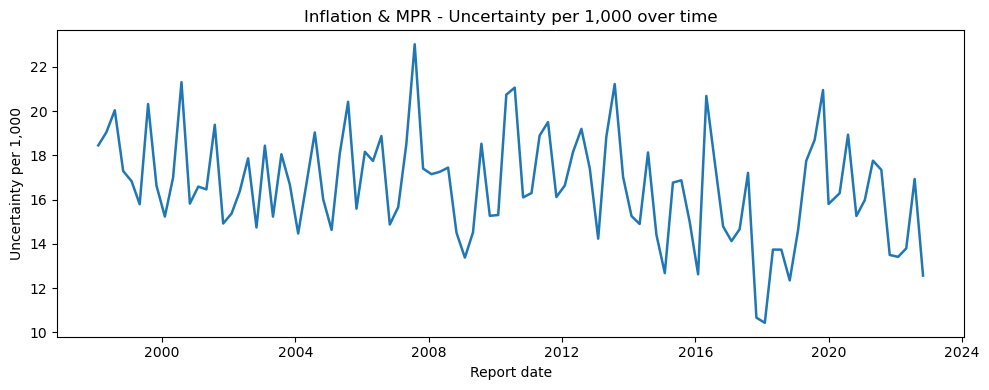

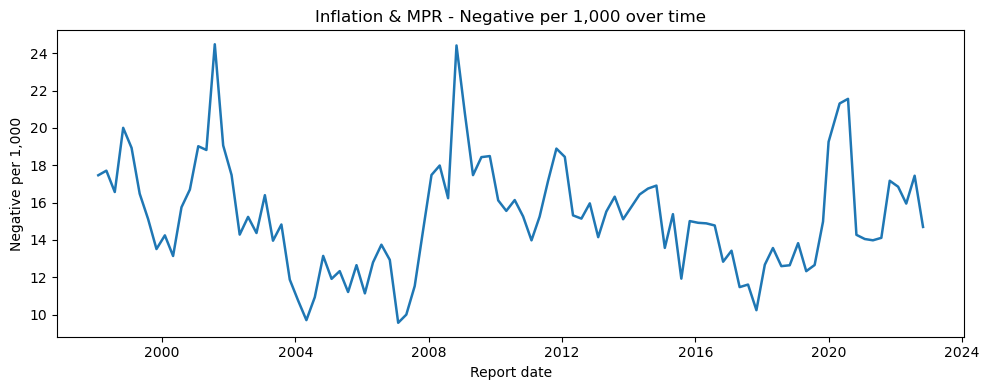

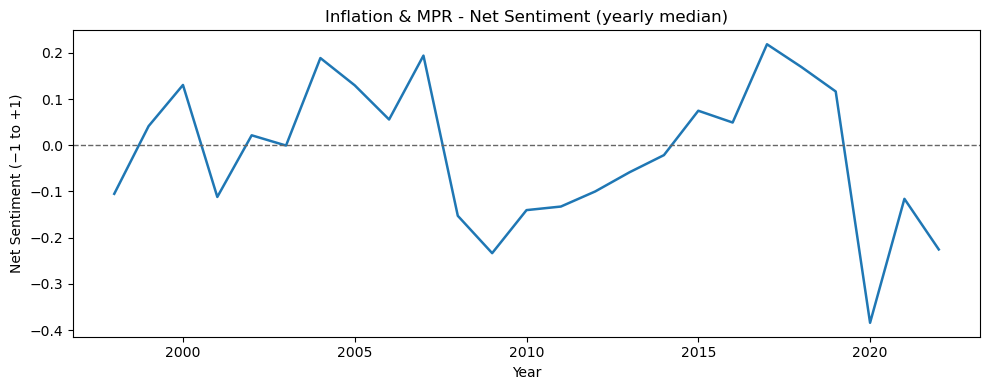

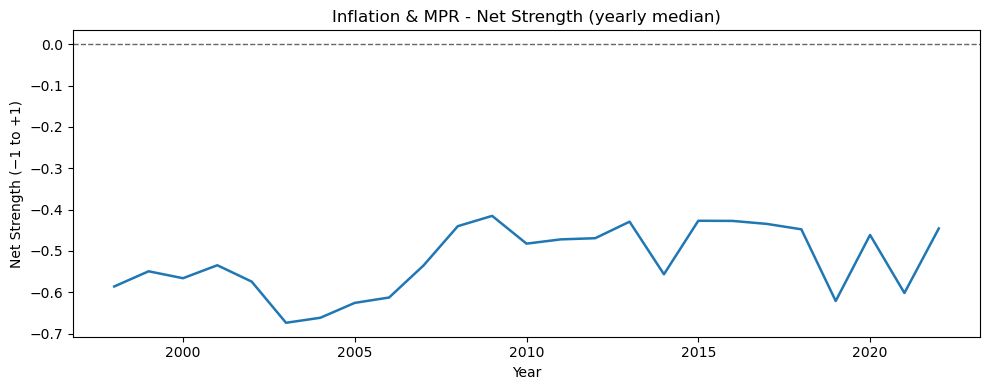

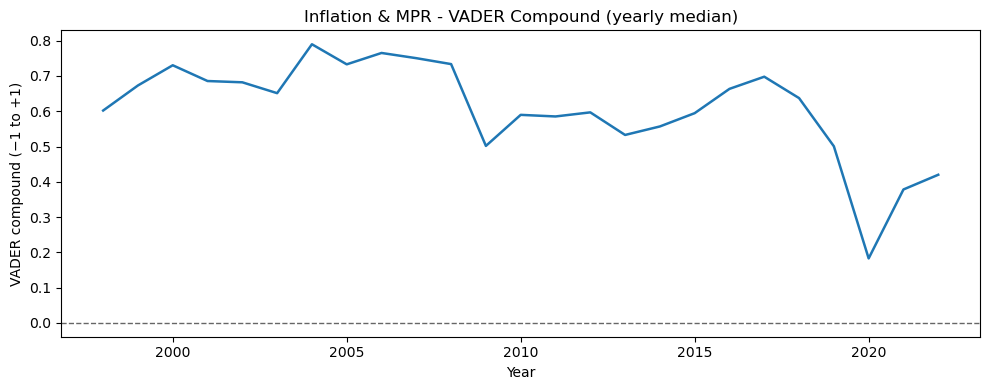

Charts saved to: outputs


In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

OUT_DIR = Path("outputs")
MERGED  = OUT_DIR / "infl_mpr_documents_summary_with_vader.csv"

# Load merged table from disk (works even if nothing is in memory)
df_models = pd.read_csv(MERGED)

# Ensure proper datetime on the x-axis (critical to avoid label clutter)
df_models["report_date"] = pd.to_datetime(
    df_models["report_date"], errors="coerce"
).fillna(pd.to_datetime(dict(year=df_models["year"],
                             month=df_models["month"].fillna(12),
                             day=1), errors="coerce"))

# Sort for plotting
x = df_models.dropna(subset=["report_date"]).sort_values("report_date")

# Common date locator/formatter (same style as FSR notebook)
major = mdates.AutoDateLocator(minticks=6, maxticks=10)
fmt   = mdates.ConciseDateFormatter(major)

# LM time-series: Uncertainty per 1,000
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x["report_date"], x["uncertainty_per_1000"], lw=1.8)
ax.set_title("Inflation & MPR - Uncertainty per 1,000 over time")
ax.set_xlabel("Report date")
ax.set_ylabel("Uncertainty per 1,000")
ax.xaxis.set_major_locator(major)
ax.xaxis.set_major_formatter(fmt)
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_uncertainty_per_1000.png", dpi=300)
plt.show()

# LM time-series: Negative per 1,000
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x["report_date"], x["negative_per_1000"], lw=1.8)
ax.set_title("Inflation & MPR - Negative per 1,000 over time")
ax.set_xlabel("Report date")
ax.set_ylabel("Negative per 1,000")
ax.xaxis.set_major_locator(major)
ax.xaxis.set_major_formatter(fmt)
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_negative_per_1000.png", dpi=300)
plt.show()

# Yearly medians: LM indices
yr = (df_models.dropna(subset=["year"])
      .groupby("year", as_index=False)[["net_sent_index", "net_strength_index"]]
      .median()
      .sort_values("year"))

fig, ax = plt.subplots(figsize= (10, 4))
ax.plot(yr["year"], yr["net_sent_index"], lw=1.8)
ax.axhline(0, ls="--", color="0.4", lw=1)
ax.set_title("Inflation & MPR - Net Sentiment (yearly median)")
ax.set_xlabel("Year")
ax.set_ylabel("Net Sentiment (−1 to +1)")
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_net_sent_yearly_median.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yr["year"], yr["net_strength_index"], lw=1.8)
ax.axhline(0, ls="--", color="0.4", lw=1)
ax.set_title("Inflation & MPR - Net Strength (yearly median)")
ax.set_xlabel("Year")
ax.set_ylabel("Net Strength (−1 to +1)")
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_net_strength_yearly_median.png", dpi=300)
plt.show()

# Yearly median: VADER compound
yr_v = (df_models.dropna(subset=["year", "vader_compound"])
        .groupby("year", as_index=False)["vader_compound"]
        .median()
        .sort_values("year"))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yr_v["year"], yr_v["vader_compound"], lw=1.8)
ax.axhline(0, ls="--", color="0.4", lw=1)
ax.set_title("Inflation & MPR - VADER Compound (yearly median)")
ax.set_xlabel("Year")
ax.set_ylabel("VADER compound (−1 to +1)")
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_vader_compound_yearly_median.png", dpi=300)
plt.show()

print("Charts saved to:", OUT_DIR)

## Step 8: Compare LM and VADER Sentiment (Yearly Medians)

We now place the two headline measures on the same axis:

- **LM Net Sentiment (median by year)**: the risk-oriented signal, based on the Loughran–McDonald dictionary.  
- **VADER Compound (median by year)**: the surface-tone signal from general English.

This mirrors the Financial Stability notebook and lets us see where the underlying risk language (LM) moves in step with, or diverges from, the outward tone (VADER). The chart is saved to `outputs/infl_mpr_lm_vs_vader_yearly_medians.png`.

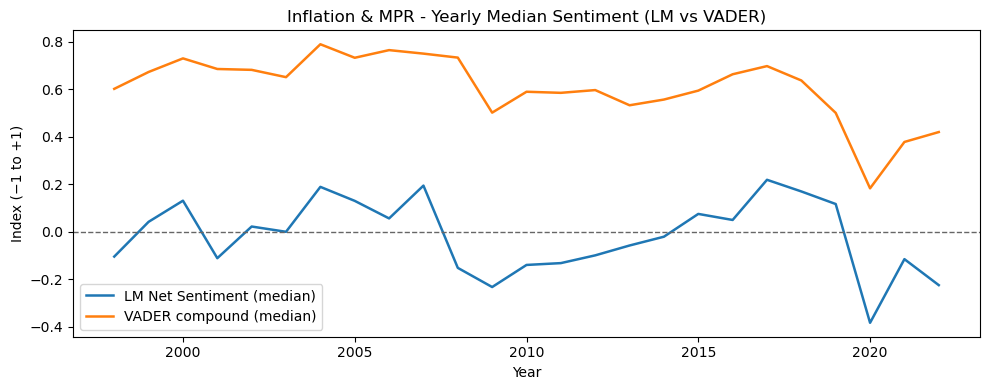

Chart saved to: outputs/infl_mpr_lm_vs_vader_yearly_medians.png


In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = Path("outputs")
MERGED  = OUT_DIR / "infl_mpr_documents_summary_with_vader.csv"

# Load merged dataset
df_models = pd.read_csv(MERGED)

# Yearly medians
trend_lm = (df_models.dropna(subset=["year", "net_sent_index"])
            .groupby("year", as_index=False)["net_sent_index"]
            .median()
            .rename(columns={"net_sent_index": "lm_net_sent_median"}))

trend_vd = (df_models.dropna(subset=["year", "vader_compound"])
            .groupby("year", as_index=False)["vader_compound"]
            .median()
            .rename(columns={"vader_compound": "vader_compound_median"}))

trend_cmp = trend_lm.merge(trend_vd, on="year", how="outer").sort_values("year")

# Plot (same look-and-feel as FSR notebook)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trend_cmp["year"], trend_cmp["lm_net_sent_median"], label="LM Net Sentiment (median)", lw=1.8)
ax.plot(trend_cmp["year"], trend_cmp["vader_compound_median"], label="VADER compound (median)", lw=1.8)
ax.axhline(0, linestyle="--", linewidth=1, color="0.4")
ax.set_title("Inflation & MPR - Yearly Median Sentiment (LM vs VADER)")
ax.set_xlabel("Year")
ax.set_ylabel("Index (−1 to +1)")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_lm_vs_vader_yearly_medians.png", dpi=300)
plt.show()

print("Chart saved to:", OUT_DIR / "infl_mpr_lm_vs_vader_yearly_medians.png")

>Both measures capture the Bank’s evolving communication tone, but in different ways.  
The **LM sentiment** (blue line) fluctuates around zero and is occasionally negative, indicating that the underlying language of the Inflation and Monetary Policy Reports remains rooted in *risk awareness* and caution.  
>The **VADER sentiment** (orange line), on the other hand, is consistently positive, showing that the surface tone of the Bank’s communication remains *reassuring and confident*, even when the economic environment is uncertain.

>**Trends over time**  
>- **Late 1990s-mid 2000s:** Both indices rise slightly. LM sentiment edges toward neutral, reflecting relatively stable growth and confidence in the policy framework during that period. VADER remains high, consistent with an outwardly optimistic communication tone.  
>- **2008-2010:** Both indicators fall. The Global Financial Crisis produces a clear dip in LM sentiment, reflecting a stronger presence of risk-related and uncertainty terms. VADER softens but remains positive, indicating that even amid crisis, the Bank’s tone aimed to project calm and credibility.  
>- **2011-2019:** Both series recover, although LM remains more cautious. The upward trend in LM sentiment suggests a gradual shift toward normalisation and renewed policy confidence as inflation stabilised and macro conditions improved.  
>- **2020-2022:** The largest joint decline since the financial crisis. LM sentiment turns sharply negative, reflecting heightened risk and uncertainty language around the pandemic, the Ukraine war, and post-Brexit dynamics. VADER also drops (its lowest reading in the series), showing that even the surface tone became noticeably less confident during this period.

>**Interpretation**  
>- The **direction of change** is aligned: both LM and VADER dip around shocks and recover during stability.  
>- The **gap between the two** reveals the Bank’s dual communication strategy — cautious in substance (LM) but generally confident in tone (VADER).  
>- The **recent narrowing of that gap** (post-2020) suggests that the Bank’s tone has become more openly cautious, reflecting the extraordinary macroeconomic and policy challenges of that period.

>**Key takeaway**  
>The Inflation and Monetary Policy Reports consistently balance technical realism with reassurance.  
>When conditions are stable, the reports lean more neutral or positive in tone.  
>When stress emerges, both measures fall, signalling that the Bank’s communication shifts toward openness about risk while still maintaining an underlying sense of stability and control.

## Step 9: Net Sentiment by Series (Inflation Report vs Monetary Policy Report)

To keep the structure aligned with the Financial Stability notebook, we also show the LM indices split by series.  
This reveals whether the transition from the **Inflation Report** to the **Monetary Policy Report** coincides with any change in risk language.

We plot two yearly-median charts by series:
- **LM Net Sentiment (median by year and series)**
- **LM Net Strength (median by year and series)**

Charts are saved to:
- `outputs/infl_mpr_net_sent_yearly_median_by_series.png`
- `outputs/infl_mpr_net_strength_yearly_median_by_series.png`

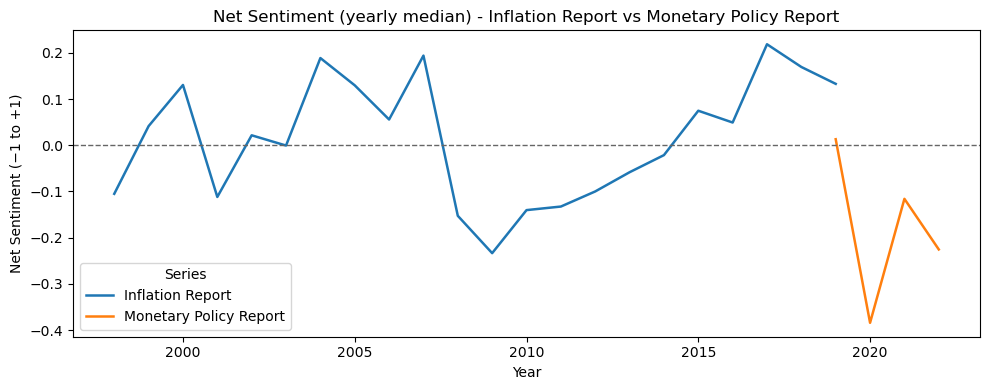

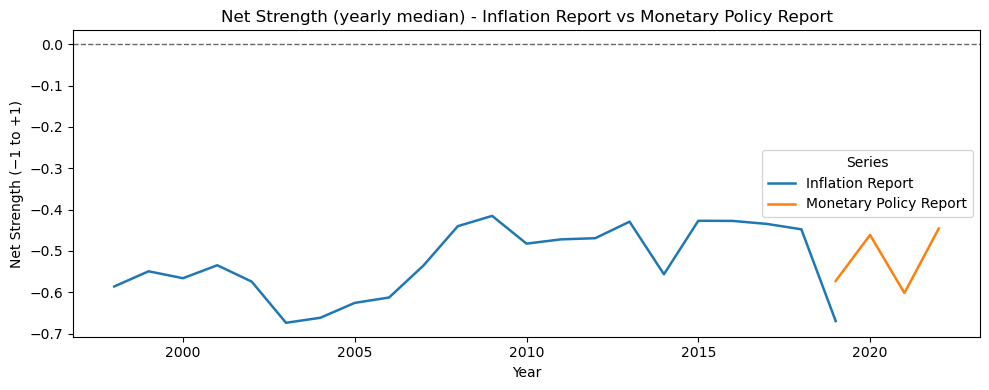

Charts saved to:
 - outputs/infl_mpr_net_sent_yearly_median_by_series.png
 - outputs/infl_mpr_net_strength_yearly_median_by_series.png


In [13]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

OUT_DIR = Path("outputs")
MERGED  = OUT_DIR / "infl_mpr_documents_summary_with_vader.csv"

# Load merged dataset
df_models = pd.read_csv(MERGED)

# Guard: ensure 'series' exists
if "series" not in df_models.columns:
    raise ValueError("Column 'series' not found. Ensure filename parsing (Step 5) created the series field.")

# Yearly medians by series
yr_series = (df_models.dropna(subset=["year", "series"])
             .groupby(["year", "series"], as_index=False)[["net_sent_index", "net_strength_index"]]
             .median()
             .sort_values(["year", "series"]))

# Pivot for plotting
pivot_ns  = yr_series.pivot(index="year", columns="series", values="net_sent_index")
pivot_str = yr_series.pivot(index="year", columns="series", values="net_strength_index")

# Net Sentiment by series
fig, ax = plt.subplots(figsize=(10, 4))
pivot_ns.plot(ax=ax, lw=1.8)
ax.axhline(0, ls="--", color="0.4", lw=1)
ax.set_title("Net Sentiment (yearly median) - Inflation Report vs Monetary Policy Report")
ax.set_xlabel("Year")
ax.set_ylabel("Net Sentiment (−1 to +1)")
ax.legend(title="Series")
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_net_sent_yearly_median_by_series.png", dpi=300)
plt.show()

# Net Strength by series
fig, ax = plt.subplots(figsize=(10, 4))
pivot_str.plot(ax=ax, lw=1.8)
ax.axhline(0, ls="--", color="0.4", lw=1)
ax.set_title("Net Strength (yearly median) - Inflation Report vs Monetary Policy Report")
ax.set_xlabel("Year")
ax.set_ylabel("Net Strength (−1 to +1)")
ax.legend(title="Series")
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_net_strength_yearly_median_by_series.png", dpi=300)
plt.show()

print("Charts saved to:")
print(" -", OUT_DIR / "infl_mpr_net_sent_yearly_median_by_series.png")
print(" -", OUT_DIR / "infl_mpr_net_strength_yearly_median_by_series.png")

>**Transition and continuity**  
>The transition from the *Inflation Report* (IR) to the *Monetary Policy Report* (MPR) in 2019 marks an important shift in format, but the underlying communication style remains recognisably BoE: cautious, measured, and grounded in transparency.  
>The two lines together show that while the structure and branding changed, the overall sentiment logic did not.

>**Net Sentiment (top chart)**  
>The *Inflation Report* series (blue line) shows a cyclical pattern.  
Sentiment improves steadily through the early 2000s, dips sharply around the financial crisis, and then rises again through the recovery years, peaking around 2016–17.  
>This upturn aligns with a period of relative macroeconomic stability and predictable inflation dynamics.

>The *Monetary Policy Report* (orange line) continues the story, but in a very different context: the pandemic, global supply shocks, and renewed inflationary pressure.  
>Unsurprisingly, the first MPRs are sharply more negative.  
>That drop doesn’t signal a change in communication style; it reflects the economic reality of 2020-21, when policy discussions became dominated by uncertainty, trade-offs, and risk management.  
>By 2022, sentiment begins to recover modestly, mirroring a shift from crisis response to policy recalibration.

>**Net Strength (bottom chart)**  
>The Net Strength line reinforces the same story in tone.  
>Across both series, it stays comfortably below zero, showing that the Bank’s language remains cautious and conditional, favouring “could,” “may,” and “might” over “will” or “must.”  
>The small uptick under the MPR period suggests slightly firmer communication, likely reflecting the Bank’s need to signal decisive policy action amid rapidly rising inflation.

>**What this tells us**  
>The continuity between the two lines is striking: the tone of the MPRs didn’t depart from the style established by the IRs; it simply inherited it in a more volatile world.  
>Both reports serve the same purpose: to explain, reassure, and maintain credibility during uncertainty.  
>The data shows that while the *content* of communication became more urgent after 2019, the *style* (fact-based, careful, and deliberately unemotional) remains at the heart of the Bank’s public voice.

>**In short**  
>> The MPRs didn’t replace the Inflation Reports in tone; they extended them into a tougher era, keeping the same discipline of cautious optimism that defines the Bank’s communication DNA.

<div class="alert alert-block alert-info">
Notebook End